In [21]:
import pandas as pd
from IPython.display import display
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score, homogeneity_completeness_v_measure
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
import warnings
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, ExtraTreesRegressor, AdaBoostClassifier, AdaBoostRegressor, GradientBoostingClassifier, GradientBoostingRegressor

In [2]:
df = pd.read_csv('datasets/Sleep_health_and_lifestyle_dataset_processed.csv')
display(df.head(2))

,person_id,gender,age,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,heart_rate,daily_steps,...,occupation_Lawyer,occupation_Manager,occupation_Nurse,occupation_Sales Representative,occupation_Salesperson,occupation_Scientist,occupation_Software Engineer,occupation_Teacher,systolic,diastolic
0,1,1,-1.753096,-1.298887,-1.09828,-0.825418,0.347021,1,1.654719,-1.619584,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.330002,-0.268102
1,2,1,-1.637643,-1.173036,-1.09828,0.039844,1.475592,0,1.170474,1.970077,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.459239,-0.755640


In [3]:
display(df.info)

<bound method DataFrame.info of      person_id  gender       age  sleep_duration  quality_of_sleep  \
0            1       1 -1.753096       -1.298887         -1.098280   
1            2       1 -1.637643       -1.173036         -1.098280   
2            3       1 -1.637643       -1.173036         -1.098280   
3            4       1 -1.637643       -1.550588         -2.771424   
4            5       1 -1.637643       -1.550588         -2.771424   
..         ...     ...       ...             ...               ...   
369        370       0  1.941401        1.218127          1.411435   
370        371       0  1.941401        1.092276          1.411435   
371        372       0  1.941401        1.218127          1.411435   
372        373       0  1.941401        1.218127          1.411435   
373        374       0  1.941401        1.218127          1.411435   

     physical_activity_level  stress_level  bmi_category  heart_rate  \
0                  -0.825418      0.347021             

Выберите подмножество признаков датасета для анализа. Например, подмножество признаков может не включать целевой признак. Количество признаков в подмножестве должно быть более двух. Полученный датасет назовем датасетом D1.

In [4]:
# Выбираем подмножество признаков из датасета, исключая целевой признак 'quality_of_sleep'
D1 = df[['age', 'sleep_duration', 'physical_activity_level', 'stress_level', 'bmi_category']]

# Проверяем, что подмножество выбрано корректно
display(D1.head())  # Отображаем первые несколько строк для проверки


,age,sleep_duration,physical_activity_level,stress_level,bmi_category
0,-1.753096,-1.298887,-0.825418,0.347021,1
1,-1.637643,-1.173036,0.039844,1.475592,0
2,-1.637643,-1.173036,0.039844,1.475592,0
3,-1.637643,-1.550588,-1.402260,1.475592,2
4,-1.637643,-1.550588,-1.402260,1.475592,2


С использованием метода главных компонент проведите для датасета D1 снижение размерности данных до двух. Полученный датасет назовем датасетом D2.

In [5]:
from sklearn.decomposition import PCA  # Импортируем класс PCA для снижения размерности

# 1. PCA - метод для снижения размерности данных
pca = PCA(n_components=2)  # Указываем, что хотим снизить размерность до 2

# 2. Применяем PCA к данным
D2 = pca.fit_transform(D1)  # Преобразуем данные D1 в D2 с помощью PCA

# 3. Преобразуем результат обратно в DataFrame для удобства
D2 = pd.DataFrame(D2, columns=['PC1', 'PC2'])  # Задаем названия для новых признаков

# Проверяем результат
display(D2.head())  # Отображаем первые несколько строк для проверки


,PC1,PC2
0,-1.979197,-0.793659
1,-2.335325,0.063059
2,-2.335325,0.063059
3,-2.930020,-0.604558
4,-2.930020,-0.604558


С использованием алгоритма t-SNE также проведите для датасета D1 снижение размерности данных до двух. Полученный датасет назовем датасетом D3.


In [6]:

from sklearn.manifold import TSNE  # Импортируем класс TSNE для снижения размерности

# 1. TSNE - метод для снижения размерности данных
tsne = TSNE(n_components=2, random_state=42)  # Указываем, что хотим снизить размерность до 2

# 2. Применяем TSNE к данным
D3 = tsne.fit_transform(D1)  # Преобразуем данные D1 в D3 с помощью TSNE

# 3. Преобразуем результат обратно в DataFrame для удобства
D3 = pd.DataFrame(D3, columns=['Dim1', 'Dim2'])  # Задаем названия для новых признаков

# Проверяем результат
display(D3.head())  # Отображаем первые несколько строк для проверки



,Dim1,Dim2
0,-129.590866,-4.902884
1,-134.583359,84.491493
2,-134.583359,84.491493
3,-160.852951,-4.404335
4,-160.852951,-4.404335


Визуализируйте точки датасетов D2 и D3. В каком случае кластеры выделены наиболее явно?

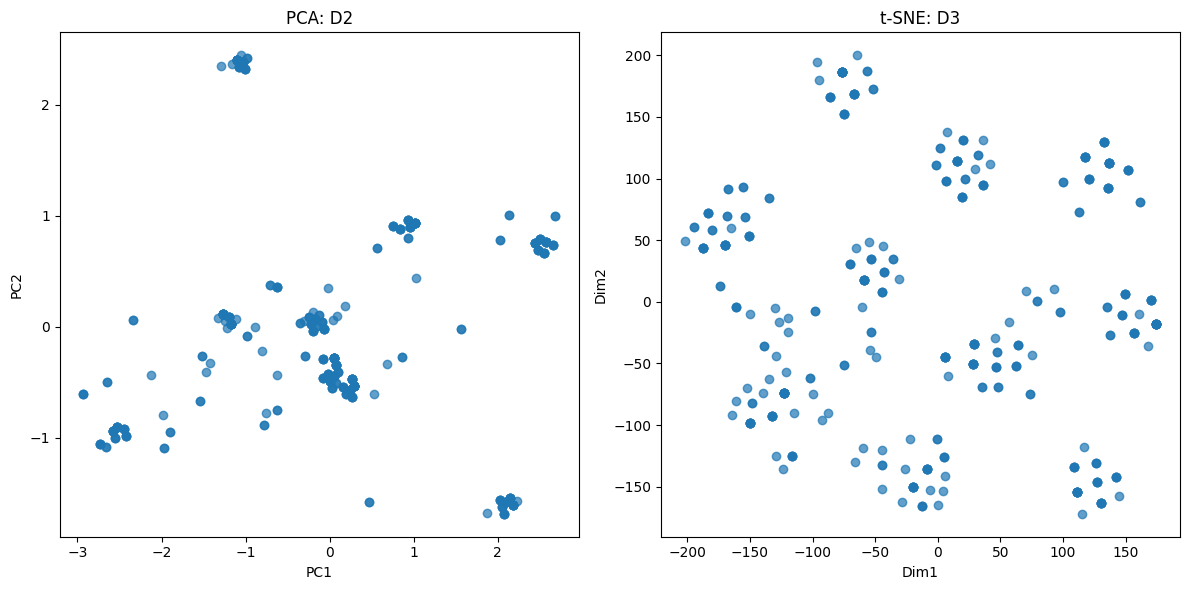

In [7]:

import matplotlib.pyplot as plt  # Импортируем библиотеку для построения графиков

# 1. Визуализация D2 - точки после применения PCA
plt.figure(figsize=(12, 6))  # Устанавливаем размер графика
plt.subplot(1, 2, 1)  # Создаем подграфик 1 из 2
plt.scatter(D2['PC1'], D2['PC2'], alpha=0.7)  # Строим точки для D2
plt.title('PCA: D2')  # Заголовок графика
plt.xlabel('PC1')  # Подпись оси X
plt.ylabel('PC2')  # Подпись оси Y

# 2. Визуализация D3 - точки после применения t-SNE
plt.subplot(1, 2, 2)  # Создаем подграфик 2 из 2
plt.scatter(D3['Dim1'], D3['Dim2'], alpha=0.7)  # Строим точки для D3
plt.title('t-SNE: D3')  # Заголовок графика
plt.xlabel('Dim1')  # Подпись оси X
plt.ylabel('Dim2')  # Подпись оси Y

plt.tight_layout()  # Обеспечиваем компактное расположение графиков
plt.show()  # Отображаем графики



In [34]:
def apply_kmeans(data, n_clusters=10):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)  # Создаем модель KMeans с 10 кластерами
    labels = kmeans.fit_predict(data)  # Применяем модель к данным и получаем метки кластеров
    return labels  # Возвращаем метки кластеров

labels_d1_kmeans = apply_kmeans(D1, n_clusters=10)  # Применяем KMeans к D1 с 10 кластерами
labels_d2_kmeans = apply_kmeans(D2, n_clusters=10)  # Применяем KMeans к D2 с 10 кластерами
labels_d3_kmeans = apply_kmeans(D3, n_clusters=10)  # Применяем KMeans к D3 с 10 кластерами

In [38]:
def apply_agglomerative(data, n_clusters=10):
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agg_clustering.fit_predict(data)
    return labels

labels_d1_agg = apply_agglomerative(D1, n_clusters=10)
labels_d2_agg = apply_agglomerative(D2, n_clusters=10)
labels_d3_agg = apply_agglomerative(D3, n_clusters=10)

In [88]:
def apply_dbscan(data, eps, min_samples=6):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)  # Создаем модель DBSCAN
    labels = dbscan.fit_predict(data)  # Применяем модель к данным и получаем метки кластеров
    return labels  # Возвращаем метки кластеров

# Применяем DBSCAN с увеличенным параметром eps
labels_d1_dbscan = apply_dbscan(D1, eps=0.5)  # Увеличиваем eps для D1
labels_d2_dbscan = apply_dbscan(D2, eps=0.2)  # Увеличиваем eps для D2
labels_d3_dbscan = apply_dbscan(D3, eps=32)    # Увеличиваем eps для D3

# Узнаем количество кластеров (не считая шум -1)
n_clusters_d1_dbscan = len(set(labels_d1_dbscan)) - (1 if -1 in labels_d1_dbscan else 0)
n_clusters_d2_dbscan = len(set(labels_d2_dbscan)) - (1 if -1 in labels_d2_dbscan else 0)
n_clusters_d3_dbscan = len(set(labels_d3_dbscan)) - (1 if -1 in labels_d3_dbscan else 0)

print(f"DBSCAN D1: {n_clusters_d1_dbscan} кластеров")
print(f"DBSCAN D2: {n_clusters_d2_dbscan} кластеров")
print(f"DBSCAN D3: {n_clusters_d3_dbscan} кластеров")

DBSCAN D1: 11 кластеров
DBSCAN D2: 9 кластеров
DBSCAN D3: 11 кластеров


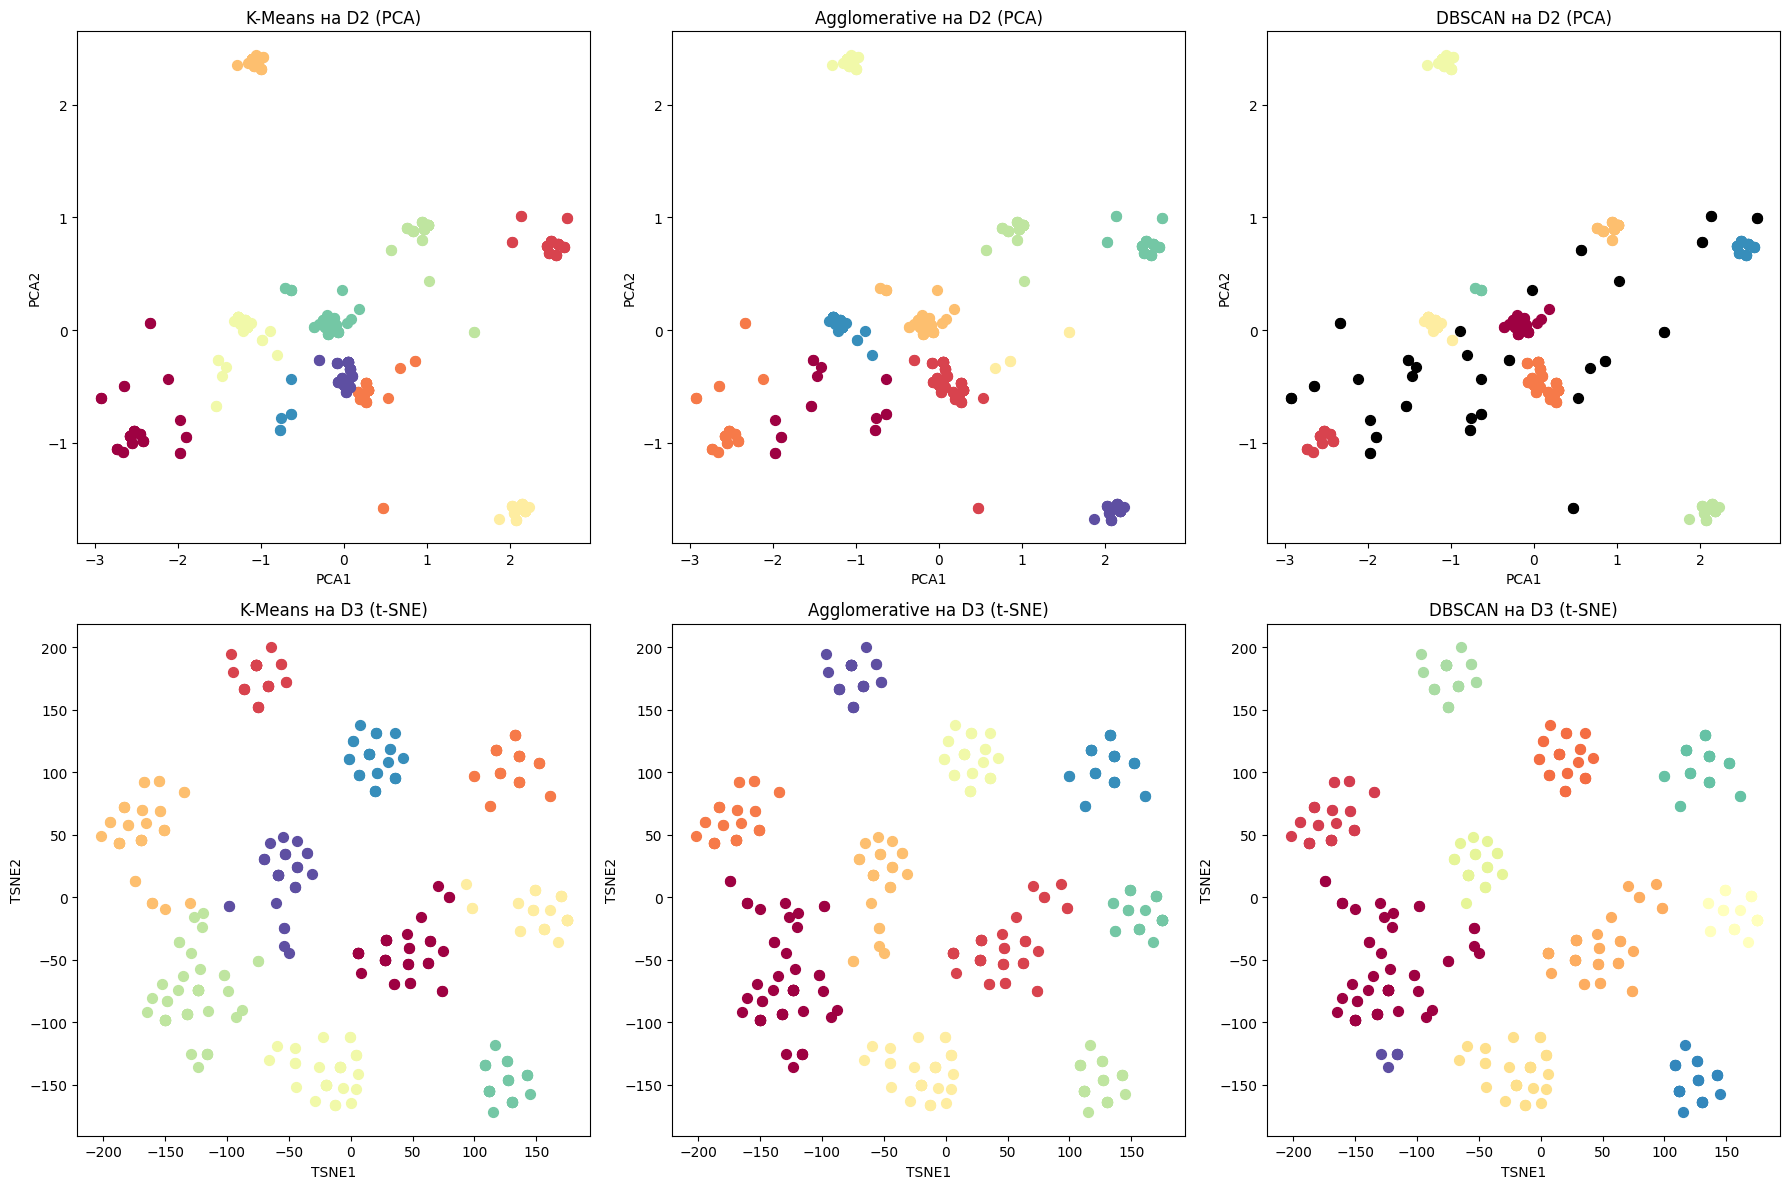

In [89]:
def plot_clusters(data, labels, title, x_label, y_label):
    unique_labels = set(labels)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Черный цвет для шума
            col = 'k'
        
        class_member_mask = (labels == k)
        xy = data[class_member_mask]
        plt.scatter(xy.iloc[:, 0], xy.iloc[:, 1], c=[col], s=50, label=f'Кластер {k}')
        
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    # plt.legend() # Легенда может быть слишком большой

plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plot_clusters(D2, labels_d2_kmeans, 'K-Means на D2 (PCA)', 'PCA1', 'PCA2')

plt.subplot(2, 3, 2)
plot_clusters(D2, labels_d2_agg, 'Agglomerative на D2 (PCA)', 'PCA1', 'PCA2')

plt.subplot(2, 3, 3)
plot_clusters(D2, labels_d2_dbscan, 'DBSCAN на D2 (PCA)', 'PCA1', 'PCA2')

plt.subplot(2, 3, 4)
plot_clusters(D3, labels_d3_kmeans, 'K-Means на D3 (t-SNE)', 'TSNE1', 'TSNE2')

plt.subplot(2, 3, 5)
plot_clusters(D3, labels_d3_agg, 'Agglomerative на D3 (t-SNE)', 'TSNE1', 'TSNE2')

plt.subplot(2, 3, 6)
plot_clusters(D3, labels_d3_dbscan, 'DBSCAN на D3 (t-SNE)', 'TSNE1', 'TSNE2')

plt.tight_layout()
plt.show()

In [90]:
def evaluate_clustering(data, labels, method_name, dataset_name):
    # Исключаем шум для DBSCAN при оценке
    if -1 in labels:
        mask = (labels != -1)
        if np.sum(mask) < 2 or len(set(labels[mask])) < 2:  # Нужно хотя бы 2 точки и 2 кластера
            return [dataset_name, method_name, np.nan]
        data_eval = data[mask]
        labels_eval = labels[mask]
    else:
        data_eval = data
        labels_eval = labels

    # Проверяем, достаточно ли кластеров
    if len(set(labels_eval)) < 2:
        return [dataset_name, method_name, np.nan]

    silhouette = silhouette_score(data_eval, labels_eval)

    return [dataset_name, method_name, silhouette]

results = []

# K-Means
results.append(evaluate_clustering(D1, labels_d1_kmeans, 'K-Means', 'D1'))
results.append(evaluate_clustering(D2, labels_d2_kmeans, 'K-Means', 'D2 (PCA)'))
results.append(evaluate_clustering(D3, labels_d3_kmeans, 'K-Means', 'D3 (t-SNE)'))

# Agglomerative
results.append(evaluate_clustering(D1, labels_d1_agg, 'Agglomerative', 'D1'))
results.append(evaluate_clustering(D2, labels_d2_agg, 'Agglomerative', 'D2 (PCA)'))
results.append(evaluate_clustering(D3, labels_d3_agg, 'Agglomerative', 'D3 (t-SNE)'))

# DBSCAN
results.append(evaluate_clustering(D1, labels_d1_dbscan, 'DBSCAN', 'D1'))
results.append(evaluate_clustering(D2, labels_d2_dbscan, 'DBSCAN', 'D2 (PCA)'))
results.append(evaluate_clustering(D3, labels_d3_dbscan, 'DBSCAN', 'D3 (t-SNE)'))

results_df = pd.DataFrame(results, columns=['Датасет', 'Метод', 'Silhouette Score'])

print("Результаты оценки качества кластеризации:")
print(results_df.round(3))


Результаты оценки качества кластеризации:
      Датасет          Метод  Silhouette Score
0          D1        K-Means             0.727
1    D2 (PCA)        K-Means             0.707
2  D3 (t-SNE)        K-Means             0.703
3          D1  Agglomerative             0.712
4    D2 (PCA)  Agglomerative             0.719
5  D3 (t-SNE)  Agglomerative             0.687
6          D1         DBSCAN             0.852
7    D2 (PCA)         DBSCAN             0.822
8  D3 (t-SNE)         DBSCAN             0.631
